## Notebook 04 (04_model_evaluation_and_comparison.ipynb)

#### Title: 04. Model Evaluation & Comparison (Project Progress II)

#### Goal: Engineer features (lags and rolling averages), train multiple regression models (Multiple Linear Regression and Ridge Regression), and evaluate performance against the naive baseline using chronological splits. 

#### Background & Next Steps:
* What I learned from the baseline: In `03_baseline_model.ipynb`, simply using last week's revenue to predict this week's revenue worked better (MAE £62,939.95) than my first linear regression model (MAE £91,790.05). The linear model stayed mostly flat and completely missed the big jump in November sales above £350,000.
* Adding more information: Instead of using only the previous week's sales, I will create new inputs such as weekly sales averages, order counts, and sales from two weeks ago to help track changes in demand.
* Comparing models: I will compare my baseline against multiple regression models using standard error scores (MAE, RMSE, and R^2).
* Testing fairly: I will train the models on the first 80% of weeks and test them on the final 20% in exact time order so the models only learn from past data.

In [1]:
# 1. Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 2. Cleaning and preparing the data
def load_and_clean_data(filepath):
    # Loading raw dataset
    raw_df = pd.read_csv(filepath, encoding='ISO-8859-1')
    df = raw_df.copy()

    # Renaming country values and removing duplicates
    df['Country'] = df['Country'].replace({'RSA': 'South Africa', 'EIRE': 'Ireland'})
    df = df.drop_duplicates()

    # Keeping valid sales and rows with a description
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df = df.dropna(subset=['Description'])

    # Converting InvoiceDate to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

    # Calculating revenue
    df['Revenue'] = df['Quantity'] * df['UnitPrice']

    # Removing administrative and postage codes
    admin_codes = ['AMAZONFEE', 'B', 'DOT', 'M', 'POST', 'S', 'm']
    df_products = df[~df['StockCode'].isin(admin_codes)].copy()

    # Loading the raw data to identify cancelled orders
    grouped = raw_df.groupby(['CustomerID', 'StockCode'])['Quantity'].sum().reset_index()
    zero_net_orders = grouped[grouped['Quantity'] == 0][['CustomerID', 'StockCode']]

    # Removing cancelled orders
    merged = df_products.merge(
        zero_net_orders, 
        on=['CustomerID', 'StockCode'], 
        how='left', 
        indicator=True
    )
    clean_df = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge']).copy()

    return clean_df

In [3]:
# 3. Running the data pipeline
clean_df = load_and_clean_data('../data/raw/E-commerce_data.csv')
print(f"Cleaned records: {clean_df.shape[0]:,}")

Cleaned records: 521,208


In [4]:
# 4. Grouping transactions into weekly totals and order counts
weekly_base = clean_df.groupby(pd.Grouper(key='InvoiceDate', freq='W-SUN')).agg(
    Revenue=('Revenue', 'sum'),
    Order_Count=('InvoiceNo', 'nunique')
).reset_index()

# Removing the final incomplete week
weekly_base = weekly_base.iloc[:-1].copy()

# Checking the total number of weeks
print("Total base weeks:", len(weekly_base))
weekly_base.head()

Total base weeks: 53


,InvoiceDate,Revenue,Order_Count
0,2010-12-05,180384.87,425
1,2010-12-12,299903.65,526
2,2010-12-19,206093.42,439
3,2010-12-26,85359.48,159
4,2011-01-02,0.00,0


In [5]:
# 5. Creating two weekly versions: zero revenue vs estimated revenue

# Version A: Keeping the holiday week at 0
weekly_zero = weekly_base.copy()

# Version B: Estimating the holiday week values
weekly_interp = weekly_base.copy()
weekly_interp['Revenue'] = weekly_interp['Revenue'].replace(0, np.nan).interpolate()
weekly_interp['Order_Count'] = weekly_interp['Order_Count'].replace(0, np.nan).interpolate()

# Comparing the holiday week rows in both versions
display(weekly_zero.iloc[2:5])
display(weekly_interp.iloc[2:5])

,InvoiceDate,Revenue,Order_Count
2,2010-12-19,206093.42,439
3,2010-12-26,85359.48,159
4,2011-01-02,0.00,0


,InvoiceDate,Revenue,Order_Count
2,2010-12-19,206093.420,439.0
3,2010-12-26,85359.480,159.0
4,2011-01-02,106851.415,200.5


## 2. Feature Engineering & Train/Test Split
In this section, I create the new inputs for both versions:
* Sales from last week (`Prior_Week_Revenue`)
* Sales from two weeks ago (`Lag_2_Revenue`)
* Orders from last week (`Prior_Week_Orders`)
* A 4-week sales average (`Rolling_4_Week_Revenue`)

Because calculating a 4-week average requires 4 weeks of past data, the first 4 weeks are left empty. I remove those empty weeks and split both versions into an 80% training set and a 20% testing set in exact time order.

In [6]:
# 6. Adding past sales, order counts, and 4-week averages

# Version A: Zero Revenue
weekly_zero['Prior_Week_Revenue'] = weekly_zero['Revenue'].shift(1)
weekly_zero['Lag_2_Revenue'] = weekly_zero['Revenue'].shift(2)
weekly_zero['Prior_Week_Orders'] = weekly_zero['Order_Count'].shift(1)
weekly_zero['Rolling_4_Week_Revenue'] = weekly_zero['Revenue'].shift(1).rolling(window=4).mean()

# Version B: Estimated Revenue
weekly_interp['Prior_Week_Revenue'] = weekly_interp['Revenue'].shift(1)
weekly_interp['Lag_2_Revenue'] = weekly_interp['Revenue'].shift(2)
weekly_interp['Prior_Week_Orders'] = weekly_interp['Order_Count'].shift(1)
weekly_interp['Rolling_4_Week_Revenue'] = weekly_interp['Revenue'].shift(1).rolling(window=4).mean()

# Checking the first few rows of both versions
display(weekly_zero.head(6))
display(weekly_interp.head(6))

,InvoiceDate,Revenue,Order_Count,Prior_Week_Revenue,Lag_2_Revenue,Prior_Week_Orders,Rolling_4_Week_Revenue
0,2010-12-05,180384.87,425,NaN,NaN,NaN,NaN
1,2010-12-12,299903.65,526,180384.87,NaN,425.0,NaN
2,2010-12-19,206093.42,439,299903.65,180384.87,526.0,NaN
3,2010-12-26,85359.48,159,206093.42,299903.65,439.0,NaN
4,2011-01-02,0.00,0,85359.48,206093.42,159.0,192935.3550
5,2011-01-09,128343.35,242,0.00,85359.48,0.0,147839.1375


,InvoiceDate,Revenue,Order_Count,Prior_Week_Revenue,Lag_2_Revenue,Prior_Week_Orders,Rolling_4_Week_Revenue
0,2010-12-05,180384.870,425.0,NaN,NaN,NaN,NaN
1,2010-12-12,299903.650,526.0,180384.870,NaN,425.0,NaN
2,2010-12-19,206093.420,439.0,299903.650,180384.87,526.0,NaN
3,2010-12-26,85359.480,159.0,206093.420,299903.65,439.0,NaN
4,2011-01-02,106851.415,200.5,85359.480,206093.42,159.0,192935.35500
5,2011-01-09,128343.350,242.0,106851.415,85359.48,200.5,174551.99125


In [7]:
# 7. Dropping rows with missing values and splitting into train/test sets by time

# Dropping initial rows that have NaN from rolling and lag calculations
clean_zero = weekly_zero.dropna().reset_index(drop=True)
clean_interp = weekly_interp.dropna().reset_index(drop=True)

# Defining features (X) and target variable (y)
feature_cols = ['Prior_Week_Revenue', 'Lag_2_Revenue', 'Prior_Week_Orders', 'Rolling_4_Week_Revenue']
target_col = 'Revenue'

# Calculating split index (80% train, 20% test)
split_idx = int(len(clean_zero) * 0.8)

# Splitting Version A (Zero Revenue)
X_train_zero = clean_zero.loc[:split_idx - 1, feature_cols]
y_train_zero = clean_zero.loc[:split_idx - 1, target_col]
X_test_zero = clean_zero.loc[split_idx:, feature_cols]
y_test_zero = clean_zero.loc[split_idx:, target_col]

# Splitting Version B (Estimated Revenue)
X_train_interp = clean_interp.loc[:split_idx - 1, feature_cols]
y_train_interp = clean_interp.loc[:split_idx - 1, target_col]
X_test_interp = clean_interp.loc[split_idx:, feature_cols]
y_test_interp = clean_interp.loc[split_idx:, target_col]

# Confirming shapes
print(f"Total modeling weeks: {len(clean_zero)}")
print(f"Train weeks: {len(X_train_zero)} | Test weeks: {len(X_test_zero)}")

Total modeling weeks: 49
Train weeks: 39 | Test weeks: 10


## 3. Model Training
In this section, I will train and generate predictions for three approaches across both data versions:
1. Baseline Model: Uses the previous week's sales directly as the forecast for this week.
2. Multiple Linear Regression:** Uses all four engineered features (`Prior_Week_Revenue`, `Lag_2_Revenue`, `Prior_Week_Orders`, and `Rolling_4_Week_Revenue`) to fit a standard trend line.
3. Ridge Regression: Uses the same four features, but keeps the model balanced so it doesn't rely too heavily on any single piece of information.

I will train each model strictly on the 39 training weeks and test them on the 10 test weeks.

In [8]:
# 8. Training models and generating predictions for both versions

# --- Version A: Zero Revenue ---
# 1. Baseline: Prior week sales directly
pred_baseline_zero = X_test_zero['Prior_Week_Revenue']

# 2. Multiple Linear Regression
lr_zero = LinearRegression()
lr_zero.fit(X_train_zero, y_train_zero)
pred_lr_zero = lr_zero.predict(X_test_zero)

# 3. Ridge Regression
ridge_zero = Ridge(alpha=1.0)
ridge_zero.fit(X_train_zero, y_train_zero)
pred_ridge_zero = ridge_zero.predict(X_test_zero)


# --- Version B: Estimated Revenue ---
# 1. Baseline: Prior week sales directly
pred_baseline_interp = X_test_interp['Prior_Week_Revenue']

# 2. Multiple Linear Regression
lr_interp = LinearRegression()
lr_interp.fit(X_train_interp, y_train_interp)
pred_lr_interp = lr_interp.predict(X_test_interp)

# 3. Ridge Regression
ridge_interp = Ridge(alpha=1.0)
ridge_interp.fit(X_train_interp, y_train_interp)
pred_ridge_interp = ridge_interp.predict(X_test_interp)

print("All models trained and predictions generated successfully.")

All models trained and predictions generated successfully.


## 4. Model Evaluation & Comparison
In this section, I will evaluate the performance of each model on the 10-week test set across both data versions:
* Metrics: I will calculate Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared score (R^2) .to compare typical error size and see how heavily large misses impact each model.
* Summary Table: I will compile the metrics into a clear comparison table to identify the model that performs best.
* Visualization: I will plot actual sales against predicted sales across the test period to see how each model handles weekly changes.

In [9]:
# 9. Evaluating models and building the comparison summary table

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper function to compute all three metrics
def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae, 2), round(rmse, 2), round(r2, 4)

# Collecting results for all models
results = [
    {"Version": "Version A (Zero)", "Model": "Baseline", **dict(zip(["MAE", "RMSE", "R2"], evaluate_predictions(y_test_zero, pred_baseline_zero)))},
    {"Version": "Version A (Zero)", "Model": "Linear Regression", **dict(zip(["MAE", "RMSE", "R2"], evaluate_predictions(y_test_zero, pred_lr_zero)))},
    {"Version": "Version A (Zero)", "Model": "Ridge Regression", **dict(zip(["MAE", "RMSE", "R2"], evaluate_predictions(y_test_zero, pred_ridge_zero)))},
    {"Version": "Version B (Interp)", "Model": "Baseline", **dict(zip(["MAE", "RMSE", "R2"], evaluate_predictions(y_test_interp, pred_baseline_interp)))},
    {"Version": "Version B (Interp)", "Model": "Linear Regression", **dict(zip(["MAE", "RMSE", "R2"], evaluate_predictions(y_test_interp, pred_lr_interp)))},
    {"Version": "Version B (Interp)", "Model": "Ridge Regression", **dict(zip(["MAE", "RMSE", "R2"], evaluate_predictions(y_test_interp, pred_ridge_interp)))},
]

# Displaying as a DataFrame
results_df = pd.DataFrame(results)
display(results_df)

,Version,Model,MAE,RMSE,R2
0,Version A (Zero),Baseline,59202.27,69075.38,-0.7327
1,Version A (Zero),Linear Regression,81984.11,92411.82,-2.1011
2,Version A (Zero),Ridge Regression,81984.13,92411.83,-2.1011
3,Version B (Interp),Baseline,59202.27,69075.38,-0.7327
4,Version B (Interp),Linear Regression,61802.95,71983.25,-0.8816
5,Version B (Interp),Ridge Regression,61802.99,71983.28,-0.8816


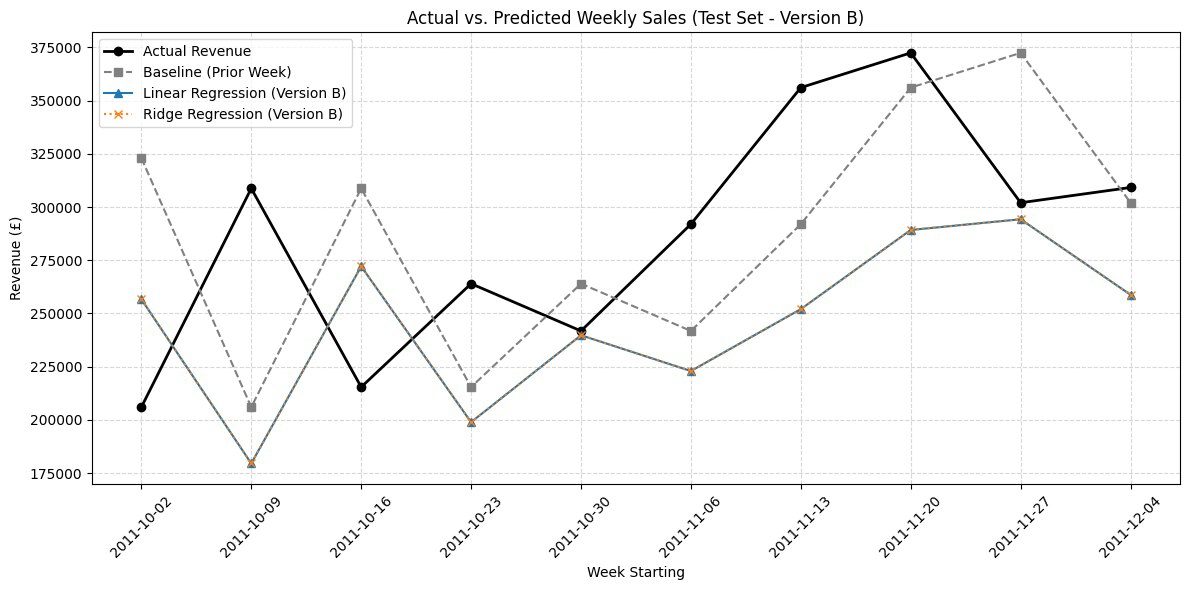

In [10]:
# 10. Visualizing Actual vs Predicted Revenue across the test weeks

plt.figure(figsize=(12, 6))

test_weeks = clean_interp.loc[split_idx:, 'InvoiceDate'].dt.strftime('%Y-%m-%d')

plt.plot(test_weeks, y_test_interp, marker='o', label='Actual Revenue', color='black', linewidth=2)
plt.plot(test_weeks, pred_baseline_interp, marker='s', linestyle='--', label='Baseline (Prior Week)', color='gray')
plt.plot(test_weeks, pred_lr_interp, marker='^', label='Linear Regression (Version B)', color='tab:blue')
plt.plot(test_weeks, pred_ridge_interp, marker='x', linestyle=':', label='Ridge Regression (Version B)', color='tab:orange')

plt.title('Actual vs. Predicted Weekly Sales (Test Set - Version B)')
plt.xlabel('Week Starting')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Results Interpretation

### 1. What the Numbers Mean for Business Planning

* Forecast Error: Over the 10 week test period, the best regression model (Version B) had a Mean Absolute Error (MAE) of £61,802.95 and a Root Mean Square Error (RMSE) of £71,983.25.
* Error Compared to Sales: Weekly revenue during the test period ranged from about £200,000 to £370,000. An average error of about £61,800 means the forecasts were often off by around 20% to 25%.
* MAE vs. RMSE: RMSE was about £10,000 higher than MAE across the models. This suggests that some weeks had much larger errors than others, especially during periods with unusual sales increases.
* Comparison to the Baseline: The simple baseline, which uses the previous week's sales as the forecast, had a lower MAE of £59,202.27. Since the regression model did not perform better than this simple method, it did not improve the forecast.

### 2. Kinds of Errors the Models Make

* Reacting Too Late: The actual vs. predicted plot shows that the models often respond to changes in sales after they happen instead of predicting them ahead of time. When sales suddenly increase, the models tend to predict lower revenue. When sales suddenly decrease, they tend to predict higher revenue based on the previous week's sales.
* Missing High Sales: During the holiday sales increase in mid to late November, actual sales went above £350,000, while the models predicted less than £300,000.

### 3. Acceptability for Business Use

* Overall Assessment: These results are not accurate enough to use the model by itself for revenue planning, inventory decisions, or warehouse staffing.
* Business Risk: If the model predicts £50,000 to £70,000 less revenue than what actually occurs during a holiday peak, a business could order too little inventory and lose sales. If it predicts too much after sales suddenly fall, the business could end up with too much inventory.
* What Would Need to Improve: Before using the model for important business decisions, it should perform better than the baseline MAE of £59,202.27, produce a positive R^2, and include information about seasons, holidays, or other calendar patterns that could help predict increases in demand ahead of time.
